In [1]:
from pydpeet.process.analyze.extract.field_data_loader import load_field_data_csv

df_field = load_field_data_csv("/Users/felixweidlich/Documents/Uni/Abschluss/pyDePEET/pydpeet/input_data/Felddaten/vin38.csv")

print(df_field.shape, df_field["Test_Time[s]"].iloc[-1] / 86400, "Tage")
df_field.head()


(4132658, 14) 939.7630787037037 Tage


,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],EIS_DC[A],Capacity[Ah],SOC,PackVoltage[V]
0,FieldData,0,3.757958,-126.3,31.5,0.0,1970-01-01 00:00:11,NaN,NaN,NaN,NaN,-0.000000,0.37,360.7
1,FieldData,0,3.758667,-126.3,32.0,10.0,1970-01-01 00:00:21,NaN,NaN,NaN,NaN,-0.350833,0.37,360.8
2,FieldData,0,3.760146,-126.1,32.0,20.0,1970-01-01 00:00:31,NaN,NaN,NaN,NaN,-0.701111,0.37,360.9
3,FieldData,0,3.761354,-126.1,32.0,30.0,1970-01-01 00:00:41,NaN,NaN,NaN,NaN,-1.051389,0.37,361.0
4,FieldData,0,3.762469,-126.2,32.0,40.0,1970-01-01 00:00:51,NaN,NaN,NaN,NaN,-1.401944,0.38,361.1


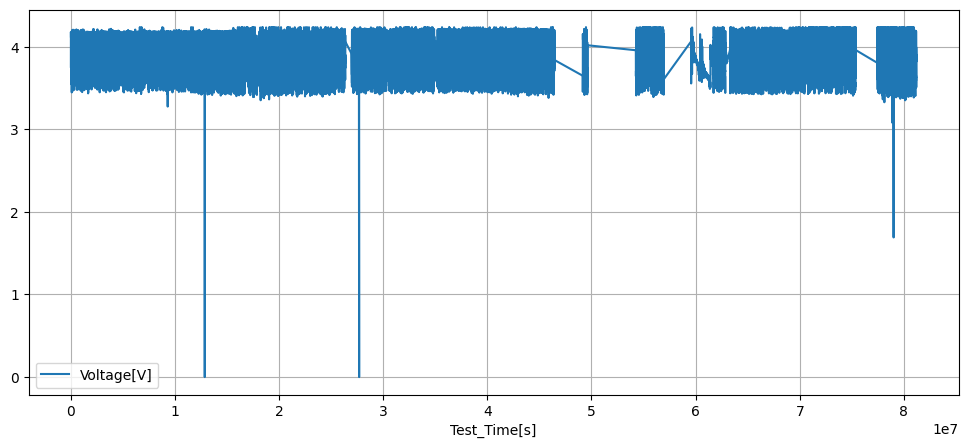

In [2]:
import matplotlib.pyplot as plt
df_field.plot(x="Test_Time[s]", y="Voltage[V]", figsize=(12, 5), grid=True)
plt.show()

In [3]:
from pydpeet.process.analyze.extract.pauses import extract_pauses
from pydpeet.process.analyze.extract.ocv_simple import pauses_to_ocv_simple

pauses  = extract_pauses(df_field, min_pause_duration_s=600)
from pydpeet.process.analyze.extract.ocv_simple import pauses_to_ocv_simple
anchors_simple = pauses_to_ocv_simple(pauses)
print(f"{len(anchors_simple)} OCV-Endpunkte")
print(anchors_simple[["pause_duration_s", "SOC", "U"]].head())

1090 OCV-Endpunkte
   pause_duration_s   SOC         U
0           19986.0  0.95  4.110708
1            3937.0  0.53  3.724021
2            1677.0  0.34  3.646958
3           17201.0  0.96  4.109979
4           20014.0  0.81  3.973417


In [4]:
from pydpeet.process.analyze.extract.haf_cell_fitting import get_best_half_cell_fit

df_for_fit = (
    anchors_simple[["SOC", "U"]]
        .rename(columns={"U": "Voltage[V]"})
        .dropna()
        .sort_values("SOC")
        .drop_duplicates(subset="SOC")
        .reset_index(drop=True)
)

best = get_best_half_cell_fit(df_for_fit, full_cell_name="FUDS_B1")
print(best)


    RMSE[mV] FullCell                        Anode                    Cathode  \
0  22.766741  FUDS_B1  Graphite, Chaouachi2021.csv  NMC622, Chaouachi2021.csv   

   Sol_Anode_Min  Sol_Anode_Max  Sol_Cathode_Min  Sol_Cathode_Max  \
0       0.109492       0.681116         0.266245         0.804738   

                                      Solution_Array  
0  [0.10949231274527202, 0.6811156451302502, 0.26...  


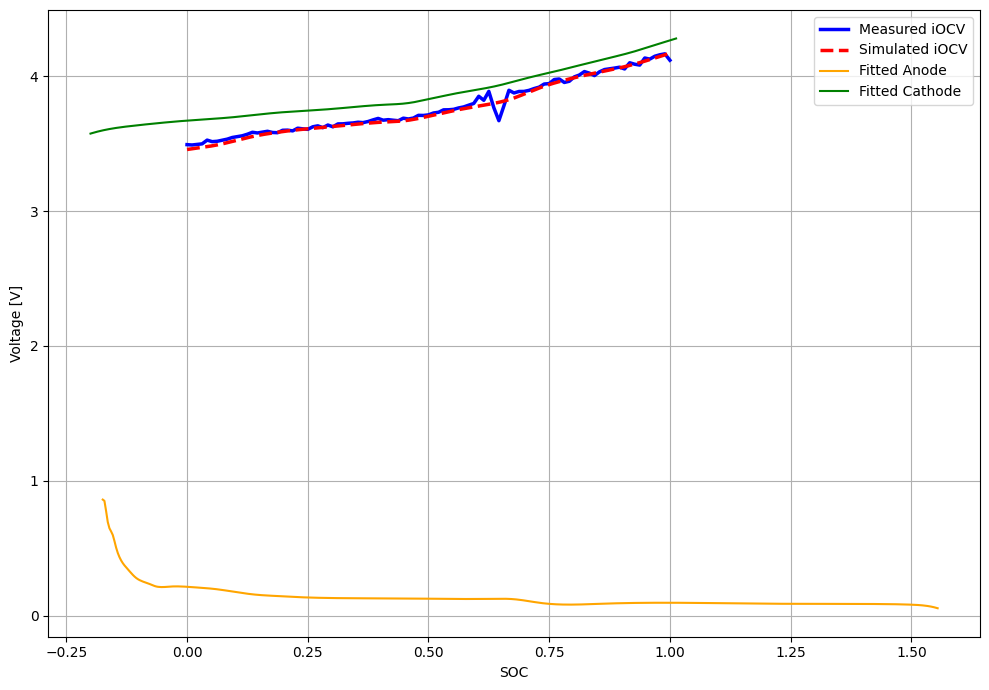

In [ ]:
import pandas as pd
from pydpeet.process.analyze.extract.haf_cell_fitting import plot_half_cell_match
best_anode_file   = best["Anode"].iloc[0]
best_cathode_file = best["Cathode"].iloc[0]
solution_array    = best["Solution_Array"].iloc[0]

anode_raw   = pd.read_csv("/Users/felixweidlich/Documents/Uni/Abschluss/pyDePEET/pydpeet/src/pydpeet/res/fitting_data/halfCellAnodes/"+ best_anode_file)
cathode_raw = pd.read_csv("/Users/felixweidlich/Documents/Uni/Abschluss/pyDePEET/pydpeet/src/pydpeet/res/fitting_data/halfCellCathodes/"+best_cathode_file)

df_for_plot = df_for_fit.copy()
soc = df_for_plot["SOC"]
df_for_plot["SOC"] = (soc - soc.min()) / (soc.max() - soc.min())

plot_half_cell_match(
    full_df=df_for_plot,
    anode_df=anode_raw,
    cathode_df=cathode_raw,
    solution_array=solution_array,
    filename="BestMatch_Real_lange_pause.png",
)

In [6]:
from pydpeet.process.analyze.extract.field_data_loader import (
    split_by_time_window,
)

chunks=split_by_time_window(df_field, window_days=30)

print(f"{len(chunks)} Fenster")
for i, c in enumerate(chunks):
    t0 = c["Test_Time[s]"].iloc[0] / 86400
    t1 = c["Test_Time[s]"].iloc[-1] / 86400
    print(f"  chunk {i}: rows={len(c):>8}, Tag {t0:.1f}–{t1:.1f}")

32 Fenster
  chunk 0: rows=  181605, Tag 0.0–30.0
  chunk 1: rows=  184930, Tag 30.0–60.0
  chunk 2: rows=  180042, Tag 61.0–90.0
  chunk 3: rows=  179132, Tag 90.0–120.0
  chunk 4: rows=  193790, Tag 120.0–150.0
  chunk 5: rows=  166814, Tag 150.0–180.0
  chunk 6: rows=  150907, Tag 180.0–210.0
  chunk 7: rows=  147378, Tag 210.0–239.9
  chunk 8: rows=  161858, Tag 240.2–270.0
  chunk 9: rows=  170260, Tag 270.2–300.0
  chunk 10: rows=  122938, Tag 300.3–330.0
  chunk 11: rows=  147848, Tag 330.0–360.0
  chunk 12: rows=  169335, Tag 360.3–390.0
  chunk 13: rows=  146210, Tag 390.3–419.9
  chunk 14: rows=  169515, Tag 420.2–449.9
  chunk 15: rows=  183274, Tag 450.3–480.0
  chunk 16: rows=  168958, Tag 480.0–510.0
  chunk 17: rows=  171908, Tag 510.0–538.0
  chunk 18: rows=    2626, Tag 569.0–569.8
  chunk 19: rows=   22862, Tag 570.3–574.0
  chunk 20: rows=   12053, Tag 628.0–630.0
  chunk 21: rows=  160683, Tag 630.0–659.0
  chunk 22: rows=    2132, Tag 689.0–689.9
  chunk 23: rows= 

In [ ]:
from pydpeet.process.analyze.extract.pauses import extract_pauses
from pydpeet.process.analyze.extract.ocv_simple import pauses_to_ocv_simple

anchors_per_chunk: list = []  
for i, chunk in enumerate(chunks):
    pauses = extract_pauses(chunk, min_pause_duration_s=600)
    if not pauses:
        anchors_per_chunk.append(None) 
        print(f"chunk {i:>2}: keine Pausen ≥ 600 s")
        continue
    anchors = pauses_to_ocv_simple(pauses)
    anchors_per_chunk.append(anchors)
    print(f"chunk {i:>2}: {len(pauses):>4} Pausen → {len(anchors):>4} OCV-Endpunkte")


chunk  0:   46 Pausen →   46 OCV-Endpunkte
chunk  1:   17 Pausen →   17 OCV-Endpunkte
chunk  2:   27 Pausen →   27 OCV-Endpunkte
chunk  3:   25 Pausen →   25 OCV-Endpunkte
chunk  4:   39 Pausen →   39 OCV-Endpunkte
chunk  5:   39 Pausen →   39 OCV-Endpunkte
chunk  6:   36 Pausen →   36 OCV-Endpunkte
chunk  7:   32 Pausen →   32 OCV-Endpunkte
chunk  8:   40 Pausen →   40 OCV-Endpunkte
chunk  9:   42 Pausen →   42 OCV-Endpunkte
chunk 10:   25 Pausen →   25 OCV-Endpunkte
chunk 11:   38 Pausen →   38 OCV-Endpunkte
chunk 12:   34 Pausen →   34 OCV-Endpunkte
chunk 13:   45 Pausen →   45 OCV-Endpunkte
chunk 14:   42 Pausen →   42 OCV-Endpunkte
chunk 15:   52 Pausen →   52 OCV-Endpunkte
chunk 16:   48 Pausen →   48 OCV-Endpunkte
chunk 17:   23 Pausen →   23 OCV-Endpunkte
chunk 18:    5 Pausen →    5 OCV-Endpunkte
chunk 19:    4 Pausen →    4 OCV-Endpunkte
chunk 20:    4 Pausen →    4 OCV-Endpunkte
chunk 21:   40 Pausen →   40 OCV-Endpunkte
chunk 22:    3 Pausen →    3 OCV-Endpunkte
chunk 23:  

In [ ]:
from pydpeet.process.analyze.extract.haf_cell_fitting import get_best_half_cell_fit

MIN_POINTS = 20 

best_per_chunk: list = [] 
for i, anchors in enumerate(anchors_per_chunk):
    if anchors is None or len(anchors) < MIN_POINTS:
        best_per_chunk.append(None)
        print(f"chunk {i:>2}: nur {0 if anchors is None else len(anchors)} OCV-Punkte → übersprungen")
        continue

    df_for_fit = (
        anchors[["SOC", "U"]]
            .rename(columns={"U": "Voltage[V]"})
            .dropna()
            .sort_values("SOC")
            .drop_duplicates(subset="SOC")
            .reset_index(drop=True)
    )
    if len(df_for_fit) < MIN_POINTS:
        best_per_chunk.append(None)
        print(f"chunk {i:>2}: nach Bereinigung nur {len(df_for_fit)} Punkte → übersprungen")
        continue

    best = get_best_half_cell_fit(df_for_fit, full_cell_name=f"chunk_{i:02d}")
    best_per_chunk.append(best)
    print(f"chunk {i:>2}: {len(df_for_fit):>3} Punkte → fit OK")


chunk  0:  32 Punkte → fit OK
chunk  1: nur 17 OCV-Punkte → übersprungen
chunk  2: nach Bereinigung nur 19 Punkte → übersprungen
chunk  3: nach Bereinigung nur 15 Punkte → übersprungen
chunk  4:  28 Punkte → fit OK
chunk  5:  23 Punkte → fit OK
chunk  6:  22 Punkte → fit OK
chunk  7:  27 Punkte → fit OK
chunk  8:  32 Punkte → fit OK
chunk  9:  30 Punkte → fit OK
chunk 10: nach Bereinigung nur 19 Punkte → übersprungen
chunk 11:  28 Punkte → fit OK
chunk 12:  25 Punkte → fit OK
chunk 13:  34 Punkte → fit OK
chunk 14:  29 Punkte → fit OK
chunk 15:  34 Punkte → fit OK
chunk 16:  30 Punkte → fit OK
chunk 17: nach Bereinigung nur 17 Punkte → übersprungen
chunk 18: nur 5 OCV-Punkte → übersprungen
chunk 19: nur 4 OCV-Punkte → übersprungen
chunk 20: nur 4 OCV-Punkte → übersprungen
chunk 21:  24 Punkte → fit OK
chunk 22: nur 3 OCV-Punkte → übersprungen
chunk 23:  46 Punkte → fit OK
chunk 24:  36 Punkte → fit OK
chunk 25:  31 Punkte → fit OK
chunk 26:  35 Punkte → fit OK
chunk 27:  32 Punkte → fi

In [3]:
from pydpeet.process.analyze.extract.haf_cell_fitting import (
    plot_half_cell_match,
    dir_anode,
    dir_cathode,
)

fits_overview = pd.concat(
    [b.assign(chunk=i) for i, b in enumerate(best_per_chunk) if b is not None and not b.empty],
    ignore_index=True,
)
top5 = fits_overview.sort_values("RMSE[mV]").head(5).reset_index(drop=True)
print(top5[["chunk", "RMSE[mV]", "Anode", "Cathode",
            "Sol_Anode_Min", "Sol_Anode_Max",
            "Sol_Cathode_Min", "Sol_Cathode_Max"]])

for _, row in top5.iterrows():
    chunk_idx = int(row["chunk"])

    df_for_fit = (
        anchors_per_chunk[chunk_idx][["SOC", "U"]]
            .rename(columns={"U": "Voltage[V]"})
            .dropna()
            .sort_values("SOC")
            .drop_duplicates(subset="SOC")
            .reset_index(drop=True)
    )

    anode_raw   = pd.read_csv(f"{dir_anode}/{row['Anode']}")
    cathode_raw = pd.read_csv(f"{dir_cathode}/{row['Cathode']}")

    print(f"\nchunk {chunk_idx:02d}  RMSE={row['RMSE[mV]']:.2f} mV  "
          f"Anode={row['Anode']}  Cathode={row['Cathode']}")
    plot_half_cell_match(
        full_df=df_for_fit,
        anode_df=anode_raw,
        cathode_df=cathode_raw,
        solution_array=row["Solution_Array"],
        filename=f"BestMatch_chunk{chunk_idx:02d}.png",
    )


NameError: name 'pd' is not defined

In [ ]:
from pydpeet.process.analyze.extract.haf_cell_fitting import find_best_half_cell_match
MAX_RMSE_MV = 50
def _chunk_to_fit_df(anchors):
    return (anchors[["SOC", "U"]]
            .rename(columns={"U": "Voltage[V]"})
            .dropna()
            .sort_values("SOC")
            .drop_duplicates(subset="SOC")
            .reset_index(drop=True))


all_pair_fits = []
for i, anchors in enumerate(anchors_per_chunk):
    if anchors is None or len(anchors) < MIN_POINTS:
        continue
    df_for_fit = _chunk_to_fit_df(anchors)
    if len(df_for_fit) < MIN_POINTS:
        continue
    ranking = find_best_half_cell_match(df_for_fit, full_cell_name=f"chunk_{i:02d}")
    if ranking.empty:
        continue
    all_pair_fits.append(ranking.assign(chunk=i))

all_pair_fits = pd.concat(all_pair_fits, ignore_index=True)
chunk_best_rmse = all_pair_fits.groupby("chunk")["RMSE[mV]"].min()
good_chunks = chunk_best_rmse[chunk_best_rmse <= MAX_RMSE_MV].index
bad_chunks  = chunk_best_rmse[chunk_best_rmse >  MAX_RMSE_MV]

if len(bad_chunks):
    print(f"Verworfen (bester Fit > {MAX_RMSE_MV} mV):")
    for c, r in bad_chunks.items():
        print(f"  chunk {c:>2}: bester RMSE {r:.1f} mV")

all_pair_fits = all_pair_fits[all_pair_fits["chunk"].isin(good_chunks)].reset_index(drop=True)
n_chunks_fitted = all_pair_fits["chunk"].nunique()
print(f"{len(good_chunks)} Chunks behalten, {len(bad_chunks)} verworfen")
print(f"{n_chunks_fitted} Chunks gefittet, "
      f"{all_pair_fits.groupby(['Anode','Cathode']).ngroups} Halbzellpaare bewertet")


Verworfen (bester Fit > 50 mV):
  chunk  4: bester RMSE 486.2 mV
  chunk  7: bester RMSE 64.3 mV
  chunk  9: bester RMSE 96.4 mV
  chunk 13: bester RMSE 70.8 mV
  chunk 30: bester RMSE 6346.0 mV
16 Chunks behalten, 5 verworfen
16 Chunks gefittet, 403 Halbzellpaare bewertet


In [ ]:

pair_consensus = (
    all_pair_fits
        .groupby(["Anode", "Cathode"])
        .agg(n_chunks=("chunk", "nunique"),
             median_rmse=("RMSE[mV]", "median"),
             mean_rmse=("RMSE[mV]", "mean"),
             max_rmse=("RMSE[mV]", "max"))
        .reset_index()
)

pair_consensus = pair_consensus[pair_consensus["n_chunks"] == n_chunks_fitted]

winners = (all_pair_fits.loc[all_pair_fits.groupby("chunk")["RMSE[mV]"].idxmin(),
                             ["Anode", "Cathode"]]
           .value_counts().rename("wins").reset_index())
pair_consensus = (pair_consensus.merge(winners, on=["Anode", "Cathode"], how="left"))
pair_consensus["wins"] = pair_consensus["wins"].fillna(0).astype(int)

pair_consensus = pair_consensus.sort_values("median_rmse").reset_index(drop=True)

print("Top-10 Halbzellpaare nach Median-RMSE über alle Chunks:")
print(pair_consensus.head(10).to_string(index=False))

fixed_anode   = pair_consensus.iloc[0]["Anode"]
fixed_cathode = pair_consensus.iloc[0]["Cathode"]
print(f"\nGewähltes Konsens-Paar: {fixed_anode}  +  {fixed_cathode}")


Top-10 Halbzellpaare nach Median-RMSE über alle Chunks:
                         Anode                   Cathode  n_chunks  median_rmse  mean_rmse  max_rmse  wins
   Graphite, Chaouachi2021.csv NMC622, Chaouachi2021.csv        16    15.478469  16.547587 36.268997     4
       Graphite, Ecker2015.csv NMC622, Chaouachi2021.csv        16    15.847611  16.625033 37.495828     2
 Graphite, Schmalstieg2018.csv NMC622, Chaouachi2021.csv        16    15.985478  16.718997 37.119887     0
Graphite-Silicon, Chen2020.csv NMC622, Chaouachi2021.csv        16    16.033291  16.705771 36.834798     0
        Graphite, Hust2019.csv       NMC622, Gao2018.csv        16    16.055538  17.458557 38.176242     0
      Graphite, Liebig2019.csv NMC622, Chaouachi2021.csv        16    16.121182  16.972527 37.610215     0
          Graphite, Li2012.csv        NMC111, Wu2012.csv        16    16.142000  16.979183 32.620332     1
      Graphite, Liebig2019.csv        NMC111, Wu2012.csv        16    16.362922  17.1643

In [ ]:
from pydpeet.process.analyze.extract.haf_cell_fitting import fit_half_cells, dir_anode, dir_cathode

anode_fix   = pd.read_csv(f"{dir_anode}/{fixed_anode}")
cathode_fix = pd.read_csv(f"{dir_cathode}/{fixed_cathode}")

rows = []
for i, anchors in enumerate(anchors_per_chunk):
    if anchors is None or len(anchors) < MIN_POINTS:
        continue
    df_for_fit = _chunk_to_fit_df(anchors)
    if len(df_for_fit) < MIN_POINTS:
        continue
    res = fit_half_cells(
        full_df=df_for_fit,
        anode_df=anode_fix,
        cathode_df=cathode_fix,
        full_cell_name=f"chunk_{i:02d}",
        anode_name=fixed_anode,
        cathode_name=fixed_cathode,
    )
    if res.empty or res["RMSE[mV]"].iloc[0] > MAX_RMSE_MV:
        print(f"chunk {i:>2}: Fit > {MAX_RMSE_MV} mV → nicht im Trend")
        continue
    rows.append(res.assign(
        chunk=i,
        t_start_day=chunks[i]["Test_Time[s]"].iloc[0] / 86400,
        t_end_day=chunks[i]["Test_Time[s]"].iloc[-1] / 86400,
    ))

stoich_trend = pd.concat(rows, ignore_index=True).sort_values("chunk").reset_index(drop=True)
print(stoich_trend[["chunk", "t_start_day", "RMSE[mV]",
                    "Sol_Anode_Min", "Sol_Anode_Max",
                    "Sol_Cathode_Min", "Sol_Cathode_Max"]].to_string(index=False))


chunk  4: Fit > 50 mV → nicht im Trend
chunk  7: Fit > 50 mV → nicht im Trend
chunk  9: Fit > 50 mV → nicht im Trend
chunk 13: Fit > 50 mV → nicht im Trend
chunk 30: Fit > 50 mV → nicht im Trend
 chunk  t_start_day  RMSE[mV]  Sol_Anode_Min  Sol_Anode_Max  Sol_Cathode_Min  Sol_Cathode_Max
     0     0.000000  9.529224       0.296383       0.641942         0.270719         0.798507
     5   150.000104 17.001856       0.061657       0.826486         0.276129         0.806534
     6   180.000069 22.175514       0.254989       0.600000         0.285663         0.830637
     8   240.234688 24.689332       0.119508       0.751903         0.277129         0.805411
    11   330.000035 17.305026       0.052101       0.886769         0.259364         0.802196
    12   360.259167 17.326741       0.039296       0.849910         0.277893         0.792102
    14   420.227303 12.195586       0.111502       0.747402         0.263882         0.822655
    15   450.272523 14.062729       0.020603       0.

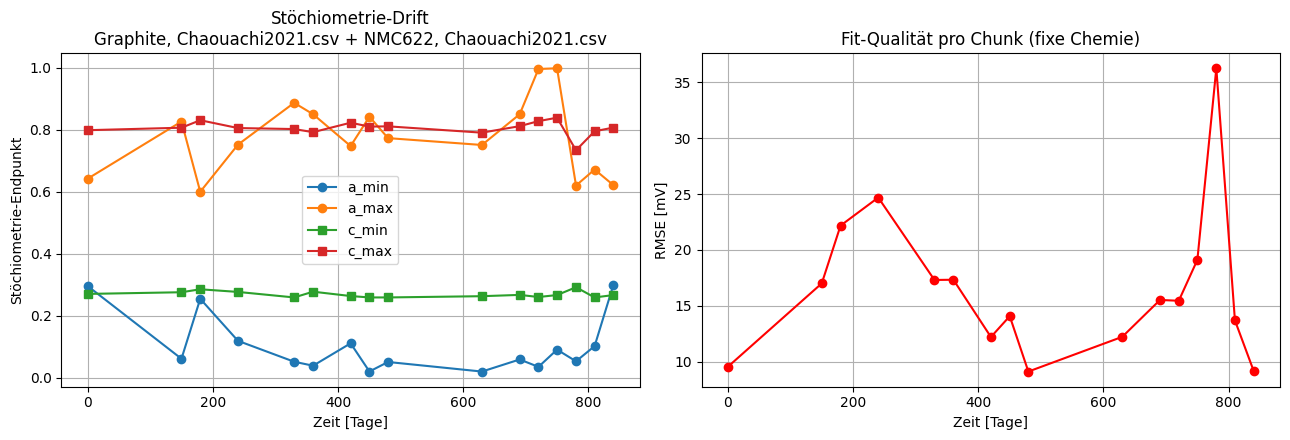

In [23]:
import matplotlib.pyplot as plt

x = stoich_trend["t_start_day"]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(x, stoich_trend["Sol_Anode_Min"],   "o-", label="a_min")
ax[0].plot(x, stoich_trend["Sol_Anode_Max"],   "o-", label="a_max")
ax[0].plot(x, stoich_trend["Sol_Cathode_Min"], "s-", label="c_min")
ax[0].plot(x, stoich_trend["Sol_Cathode_Max"], "s-", label="c_max")
ax[0].set_xlabel("Zeit [Tage]"); ax[0].set_ylabel("Stöchiometrie-Endpunkt")
ax[0].set_title(f"Stöchiometrie-Drift\n{fixed_anode} + {fixed_cathode}")
ax[0].legend(); ax[0].grid(True)

ax[1].plot(x, stoich_trend["RMSE[mV]"], "o-", color="red")
ax[1].set_xlabel("Zeit [Tage]"); ax[1].set_ylabel("RMSE [mV]")
ax[1].set_title("Fit-Qualität pro Chunk (fixe Chemie)")
ax[1].grid(True)
plt.tight_layout(); plt.show()


   RMSE[mV]                  Anode               Cathode  Sol_Anode_Min  Sol_Anode_Max  Sol_Cathode_Min  Sol_Cathode_Max
6346.026318 Graphite, Hust2019.csv LMO, Albertus2009.csv            0.3       0.998369         0.350752              0.6


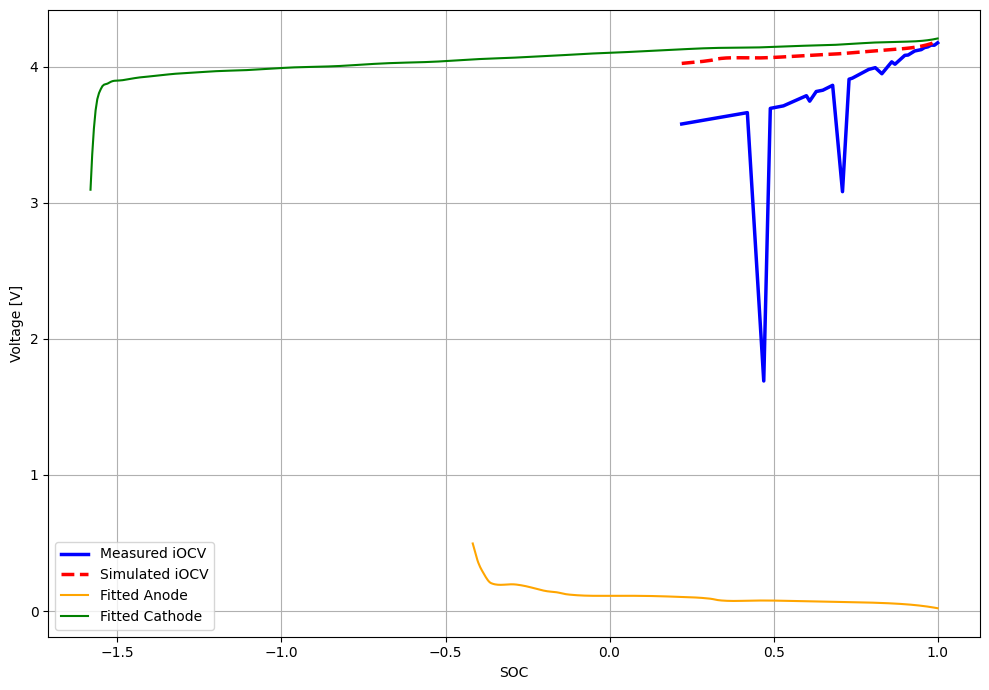

In [ ]:
import pandas as pd
from pydpeet.process.analyze.extract.haf_cell_fitting import (
    get_best_half_cell_fit, plot_half_cell_match, dir_anode, dir_cathode,
)

CHUNK = 30

df_for_fit = (
    anchors_per_chunk[CHUNK][["SOC", "U"]]
        .rename(columns={"U": "Voltage[V]"})
        .dropna()
        .sort_values("SOC")
        .drop_duplicates(subset="SOC")
        .reset_index(drop=True)
)

best = get_best_half_cell_fit(df_for_fit, full_cell_name=f"chunk_{CHUNK:02d}")
print(best[["RMSE[mV]", "Anode", "Cathode",
            "Sol_Anode_Min", "Sol_Anode_Max",
            "Sol_Cathode_Min", "Sol_Cathode_Max"]].to_string(index=False))

anode_raw   = pd.read_csv(f"{dir_anode}/{best['Anode'].iloc[0]}")
cathode_raw = pd.read_csv(f"{dir_cathode}/{best['Cathode'].iloc[0]}")

plot_half_cell_match(
    full_df=df_for_fit,                  
    anode_df=anode_raw,
    cathode_df=cathode_raw,
    solution_array=best["Solution_Array"].iloc[0],
    filename=f"BestMatch_chunk{CHUNK:02d}.png",
)


In [ ]:
from pydpeet.process.analyze.extract.fit_real_data import fit_real_data

result = fit_real_data(df_field,max_rmse_mv=30,sort_by="mean")         
print(result.head(10).to_string(index=False))


chunk  0:  32 Punkte → fit OK
chunk  1: nur 17 OCV-Punkte → übersprungen
chunk  2: nur 19 OCV-Punkte → übersprungen
chunk  3: nur 15 OCV-Punkte → übersprungen
chunk  4:  28 Punkte → fit OK
chunk  5:  23 Punkte → fit OK
chunk  6:  22 Punkte → fit OK
chunk  7:  27 Punkte → fit OK
chunk  8:  32 Punkte → fit OK
chunk  9:  30 Punkte → fit OK
chunk 10: nur 19 OCV-Punkte → übersprungen
chunk 11:  28 Punkte → fit OK
chunk 12:  25 Punkte → fit OK
chunk 13:  34 Punkte → fit OK
chunk 14:  29 Punkte → fit OK
chunk 15:  34 Punkte → fit OK
chunk 16:  30 Punkte → fit OK
chunk 17: nur 17 OCV-Punkte → übersprungen
chunk 18: nur 5 OCV-Punkte → übersprungen
chunk 19: nur 4 OCV-Punkte → übersprungen
chunk 20: nur 4 OCV-Punkte → übersprungen
chunk 21:  24 Punkte → fit OK
chunk 22: nur 3 OCV-Punkte → übersprungen
chunk 23:  46 Punkte → fit OK
chunk 24:  36 Punkte → fit OK
chunk 25:  31 Punkte → fit OK
chunk 26:  35 Punkte → fit OK
chunk 27:  32 Punkte → fit OK
chunk 28:  29 Punkte → fit OK
chunk 29: nur 10 